# SpatioEv Tutorial 00: Segmentation QC


            This refined notebook turns the original segmentation-QC scratchpad into a reproducible first
            tutorial. The goal is to flag cells whose segmentation-derived morphology is biologically
            implausible before downstream phenotyping or spatial statistics. Very small cells often
            represent debris or fragmented masks; very large cells can represent merged objects; extreme
            nuclear-to-cell ratios often indicate nucleus/cytoplasm mask mismatch.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt

import spatioev as sv

ROOT = Path.cwd()
if not (ROOT / "spatioev").exists():
    for candidate in ROOT.parents:
        if (candidate / "spatioev").exists():
            ROOT = candidate
            break

DATA_DIR = ROOT / "data"
RESULT_DIR = ROOT / "results"
RESULT_DIR.mkdir(exist_ok=True)

EXP1_H5AD = DATA_DIR / "exp_1" / "exp_1.h5ad"
QC_SUMMARY_PATH = RESULT_DIR / "segmentation_qc_summary.csv"

REQUIRED_OBS_COLUMNS = ["imageid", "area", "nc_ratio"]

if not EXP1_H5AD.exists():
    raise FileNotFoundError(f"Expected example AnnData at {EXP1_H5AD}")

adata = sv.io.load_h5ad(EXP1_H5AD)
missing = [column for column in REQUIRED_OBS_COLUMNS if column not in adata.obs.columns]
if missing:
    raise ValueError(
        f"Missing required segmentation QC columns in adata.obs: {missing}. "
        "This tutorial expects real morphology/QC measurements, not synthetic placeholders."
    )

adata.obs["imageid"] = adata.obs["imageid"].astype(str)

print(f"SpatioEv {sv.__version__}")
print(f"Using local example data: {EXP1_H5AD.relative_to(ROOT)}: {adata.n_obs:,} cells x {adata.n_vars:,} markers")
print("Image IDs:", sorted(adata.obs["imageid"].astype(str).unique()))


SpatioEv 0.1.0
Using local example data: data/exp_1/exp_1.h5ad: 51,932 cells x 25 markers
Image IDs: ['exp']


## Configure QC thresholds

In [2]:
qc_config = sv.pp.QCConfig(
    pixel_size=0.325,
    min_area_um2=10,
    max_area_um2=1000,
    max_nc_ratio=1.0,
)
print(qc_config)

QCConfig(pixel_size=0.325, min_area_um2=10, max_area_um2=1000, max_nc_ratio=1.0)


## Run segmentation QC

In [3]:
required = ["area", "nc_ratio"]
missing = [col for col in required if col not in adata.obs.columns]
if missing:
    raise ValueError(f"Missing required QC columns: {missing}")

adata_qc = sv.pp.run_segmentation_qc(adata.copy(), qc_config)
display(adata_qc.obs[["area", "area_um2", "area_category", "nc_ratio", "nc_ratio_category"]].head())

,area,area_um2,area_category,nc_ratio,nc_ratio_category
exp_0,446.0,47.108750,normal_area,1.430493,abnormal_nc_ratio
exp_1,137.0,14.470625,normal_area,0.912409,normal_nc_ratio
exp_2,620.0,65.487500,normal_area,1.146774,abnormal_nc_ratio
exp_3,1109.0,117.138125,normal_area,1.464382,abnormal_nc_ratio
exp_4,683.0,72.141875,normal_area,1.002928,abnormal_nc_ratio


## Interpret flagged cells

In [4]:
area_counts = (
    adata_qc.obs["area_category"]
    .astype(str)
    .value_counts()
    .rename_axis("area_category")
    .to_frame("n_cells")
)
nc_counts = (
    adata_qc.obs["nc_ratio_category"]
    .astype(str)
    .value_counts()
    .rename_axis("nc_ratio_category")
    .to_frame("n_cells")
)

display(area_counts)
display(nc_counts)

flagged_mask = (
    (adata_qc.obs["area_category"] != "normal_area")
    | (adata_qc.obs["nc_ratio_category"] != "normal_nc_ratio")
)
n_flagged = int(flagged_mask.sum())
print(f"Flagged cells: {n_flagged:,} / {adata_qc.n_obs:,} ({n_flagged / adata_qc.n_obs:.1%})")


,n_cells
area_category,
normal_area,51143
debris_fragment,789


,n_cells
nc_ratio_category,
normal_nc_ratio,48134
abnormal_nc_ratio,3798


Flagged cells: 4,304 / 51,932 (8.3%)


## Visualize QC distributions

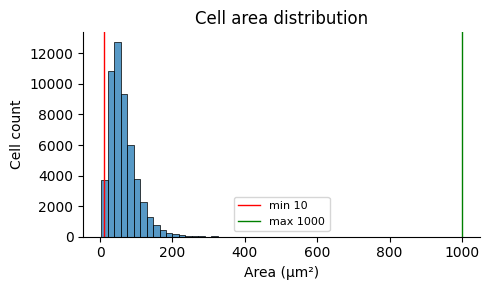

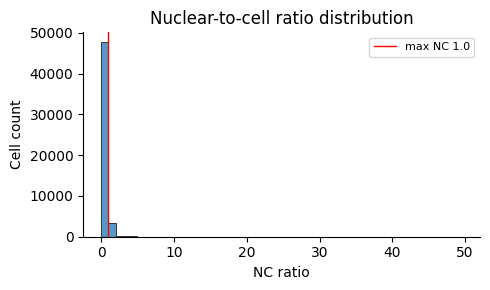

In [5]:
sv.pl.plot_area_distribution(
    adata_qc,
    min_area=qc_config.min_area_um2,
    max_area=qc_config.max_area_um2,
)
plt.show()
plt.close("all")

sv.pl.plot_nc_ratio_distribution(
    adata_qc,
    max_ratio=qc_config.max_nc_ratio,
)
plt.show()
plt.close("all")

## Filter cells and summarize by image

In [6]:
adata_filtered = sv.pp.filter_segmentation_errors(adata_qc)
summary = sv.pp.generate_qc_summary(adata_qc, groupby="imageid")
display(summary.head())

print(f"Original cells: {adata_qc.n_obs:,}")
print(f"Retained cells:  {adata_filtered.n_obs:,}")
print(f"Removed cells:   {adata_qc.n_obs - adata_filtered.n_obs:,}")

,imageid,total_cells,normal_cells,debris_fragment,merged_cell,abnormal_nc_ratio,removed_total,percent_removed
0,exp,51932,47345,789,0,3798,4587,8.83


Original cells: 51,932
Retained cells:  47,628
Removed cells:   4,304


## Save lightweight QC outputs

In [7]:
summary.to_csv(QC_SUMMARY_PATH, index=False)
print(f"Wrote {QC_SUMMARY_PATH.relative_to(ROOT)}")


Wrote results/segmentation_qc_summary.csv
